# 06 — Best Pair Report & Investment Thesis

Loads the best pair identified in Notebook 05 and produces a full analysis:

1. **Why this pair?** — factor divergence, fundamental contrast, residual correlation  
2. **Backtest performance** — cumulative P&L, monthly returns, drawdown  
3. **Weight split analysis** — why the optimal ratio beats 50/50 and beta-neutral  
4. **Correlation & spread dynamics** — rolling correlation, co-integration test  
5. **Pitch-ready summary table** with all key metrics

In [1]:
import os, sys, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import coint
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
sys.path.insert(0, '.')
from config import *
print('Ready.')

Ready.


In [2]:
# Load best pair metadata from notebook 05
with open(DATA_DIR + 'best_pair_meta.json') as f:
    meta = json.load(f)

LONG_S  = meta['long']
SHORT_S = meta['short']
W_LONG  = meta['w_long']
W_SHORT = meta['w_short']
RATIO   = meta['ratio']

print(f'Best pair: {LONG_S} (Long {W_LONG:.1%}) / {SHORT_S} (Short {W_SHORT:.1%})')
print(f'w_long/w_short ratio: {RATIO:.2f}  (1.0 = dollar-neutral, {meta["beta_neutral_ratio"]:.2f} = beta-neutral)')

# Load data
prices   = pd.read_parquet(DATA_DIR + 'prices.parquet')
returns  = pd.read_parquet(DATA_DIR + 'returns.parquet')
bt_df    = pd.read_parquet(DATA_DIR + 'best_pair_bt.parquet')
screen   = pd.read_parquet(DATA_DIR + 'pair_screening.parquet')
fund_df  = pd.read_parquet(DATA_DIR + 'fundamentals.parquet')
factor_z = pd.read_parquet(DATA_DIR + 'factor_scores.parquet')

if LONG_S not in fund_df.index:
    fund_df = fund_df.T

rl = returns[LONG_S]
rs = returns[SHORT_S]
idx = rl.index.intersection(rs.index)
rl, rs = rl.loc[idx], rs.loc[idx]

Best pair: GEVO (Long 35.5%) / LCID (Short 64.5%)
w_long/w_short ratio: 0.55  (1.0 = dollar-neutral, 0.67 = beta-neutral)


## 1. Why This Pair?

### Factor Divergence Analysis

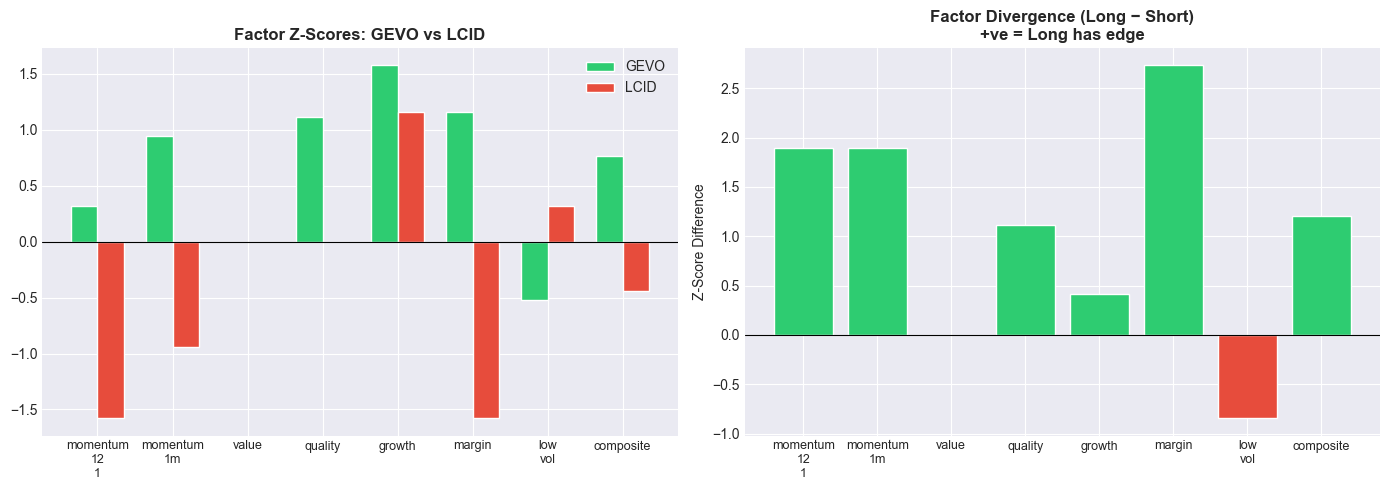


Factor Divergence Summary:


,momentum_12_1,momentum_1m,value,quality,growth,margin,low_vol,composite
Divergence (Long - Short),1.8900,1.8900,NaN,1.1180,0.4200,2.7310,-0.8400,1.2020


In [3]:
factor_cols = [c for c in ['momentum_12_1', 'momentum_1m', 'value', 'quality',
                             'growth', 'margin', 'low_vol', 'composite']
               if c in factor_z.columns]

pair_factors = factor_z.loc[[LONG_S, SHORT_S], factor_cols].copy() if LONG_S in factor_z.index else None

if pair_factors is not None:
    divergence = pair_factors.loc[LONG_S] - pair_factors.loc[SHORT_S]
    divergence.name = 'Divergence (Long - Short)'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Factor comparison bar
    x = np.arange(len(factor_cols))
    w = 0.35
    axes[0].bar(x - w/2, pair_factors.loc[LONG_S, factor_cols],  w, label=LONG_S,  color='#2ecc71', edgecolor='white')
    axes[0].bar(x + w/2, pair_factors.loc[SHORT_S, factor_cols], w, label=SHORT_S, color='#e74c3c', edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([c.replace('_', '\n') for c in factor_cols], fontsize=9)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title(f'Factor Z-Scores: {LONG_S} vs {SHORT_S}', fontsize=12, fontweight='bold')
    axes[0].legend()

    # Divergence
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in divergence.values]
    axes[1].bar(divergence.index, divergence.values, color=colors, edgecolor='white')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticklabels([c.replace('_', '\n') for c in divergence.index], fontsize=9)
    axes[1].set_title(f'Factor Divergence (Long − Short)\n+ve = Long has edge', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Z-Score Difference')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + '06_factor_divergence.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nFactor Divergence Summary:')
    display(divergence.to_frame().T.round(3))
else:
    print(f'Factor scores not available for {LONG_S} or {SHORT_S}.')

### Fundamental Contrast

In [4]:
fund_metrics = ['market_cap_bn', 'beta', 'pe_trailing', 'pe_forward',
                'ev_ebitda', 'roe', 'net_margin', 'revenue_growth',
                'earnings_growth', 'debt_equity', 'gross_margin']

avail = [m for m in fund_metrics if m in fund_df.columns]
fund_pair = fund_df.loc[[LONG_S, SHORT_S], avail].copy() if SHORT_S in fund_df.index else fund_df.reindex([LONG_S, SHORT_S])[avail]

for col in avail:
    fund_pair[col] = pd.to_numeric(fund_pair[col], errors='coerce')

def fmt_fund(val, col):
    if pd.isna(val): return 'N/A'
    if 'growth' in col or 'margin' in col or 'roe' in col: return f'{val:.1%}'
    if col == 'market_cap_bn': return f'${val:.1f}B'
    if col in ('pe_trailing', 'pe_forward', 'ev_ebitda'): return f'{val:.1f}x'
    return f'{val:.2f}'

fund_display = pd.DataFrame({
    LONG_S:  {m: fmt_fund(fund_pair.loc[LONG_S,  m], m) for m in avail if LONG_S  in fund_pair.index},
    SHORT_S: {m: fmt_fund(fund_pair.loc[SHORT_S, m], m) for m in avail if SHORT_S in fund_pair.index},
})
fund_display.index.name = 'Metric'

print(f'Fundamental Comparison: {LONG_S} vs {SHORT_S}')
display(fund_display)
fund_display.to_csv(OUTPUT_DIR + 'fund_comparison.csv')

Fundamental Comparison: GEVO vs LCID


,GEVO,LCID
Metric,,
market_cap_bn,$0.6B,$3.2B
beta,1.52,1.19
pe_trailing,N/A,N/A
pe_forward,-119.0x,-2.2x
ev_ebitda,101.8x,-2.3x
roe,-6.8%,-66.0%
net_margin,-21.1%,-199.3%
revenue_growth,695.6%,122.9%
earnings_growth,N/A,N/A


## 2. Correlation & Spread Dynamics

### Rolling Correlation and Co-integration Test

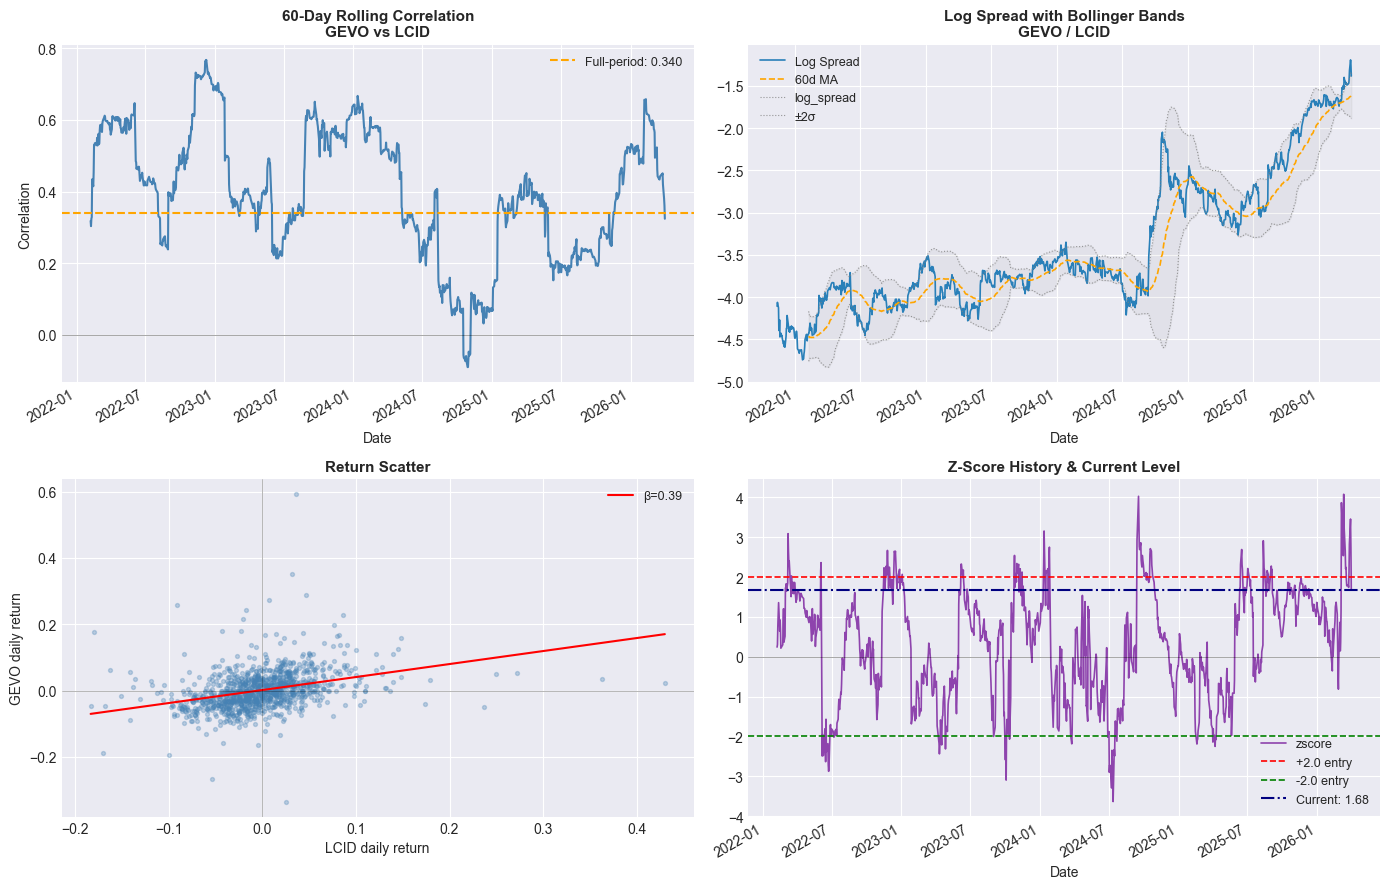

Engle-Granger co-integration test:
  Test stat : -2.6014
  p-value   : 0.2363  (not cointegrated at 5%)
  Crit vals : 1%=-3.906, 5%=-3.342, 10%=-3.048


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Rolling 60-day correlation
roll_corr = rl.rolling(60).corr(rs)
roll_corr.plot(ax=axes[0, 0], color='steelblue', linewidth=1.5)
axes[0, 0].axhline(rl.corr(rs), color='orange', lw=1.5, linestyle='--',
                    label=f'Full-period: {rl.corr(rs):.3f}')
axes[0, 0].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[0, 0].set_title(f'60-Day Rolling Correlation\n{LONG_S} vs {SHORT_S}', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Correlation')
axes[0, 0].legend(fontsize=9)

# Log spread with Bollinger bands
log_spr  = bt_df['log_spread'].dropna()
roll_mu  = log_spr.rolling(ZSCORE_WINDOW).mean()
roll_sd  = log_spr.rolling(ZSCORE_WINDOW).std()
log_spr.plot(ax=axes[0, 1], color='#2980b9', linewidth=1.2, label='Log Spread')
roll_mu.plot(ax=axes[0, 1], color='orange', lw=1.2, linestyle='--', label=f'{ZSCORE_WINDOW}d MA')
(roll_mu + 2 * roll_sd).plot(ax=axes[0, 1], color='grey', lw=0.8, linestyle=':', alpha=0.8)
(roll_mu - 2 * roll_sd).plot(ax=axes[0, 1], color='grey', lw=0.8, linestyle=':', alpha=0.8, label='±2σ')
axes[0, 1].fill_between(log_spr.index,
                         roll_mu - 2 * roll_sd, roll_mu + 2 * roll_sd,
                         alpha=0.08, color='grey')
axes[0, 1].set_title(f'Log Spread with Bollinger Bands\n{LONG_S} / {SHORT_S}', fontsize=11, fontweight='bold')
axes[0, 1].legend(fontsize=9)

# Return scatter
axes[1, 0].scatter(rs, rl, alpha=0.3, s=8, color='steelblue')
m, b = np.polyfit(rs.dropna(), rl.reindex(rs.dropna().index).dropna(), 1)
x_line = np.linspace(rs.min(), rs.max(), 100)
axes[1, 0].plot(x_line, m * x_line + b, color='red', lw=1.5, label=f'β={m:.2f}')
axes[1, 0].axhline(0, color='black', lw=0.5, alpha=0.4)
axes[1, 0].axvline(0, color='black', lw=0.5, alpha=0.4)
axes[1, 0].set_xlabel(f'{SHORT_S} daily return')
axes[1, 0].set_ylabel(f'{LONG_S} daily return')
axes[1, 0].set_title('Return Scatter', fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=9)

# Z-score current level
zsc = bt_df['zscore'].dropna()
zsc.plot(ax=axes[1, 1], color='#8e44ad', linewidth=1.2)
axes[1, 1].axhline( ZSCORE_ENTRY,  color='red',   lw=1.2, linestyle='--', label=f'+{ZSCORE_ENTRY} entry')
axes[1, 1].axhline(-ZSCORE_ENTRY,  color='green', lw=1.2, linestyle='--', label=f'-{ZSCORE_ENTRY} entry')
axes[1, 1].axhline(0, color='black', lw=0.6, alpha=0.4)
cur_z = float(zsc.iloc[-1])
axes[1, 1].axhline(cur_z, color='navy', lw=1.5, linestyle='-.',
                    label=f'Current: {cur_z:.2f}')
axes[1, 1].set_title('Z-Score History & Current Level', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '06_correlation_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

# Co-integration test (Engle-Granger)
try:
    coint_t, coint_p, crit = coint(prices[LONG_S].loc[idx], prices[SHORT_S].loc[idx])
    print(f'Engle-Granger co-integration test:')
    print(f'  Test stat : {coint_t:.4f}')
    print(f'  p-value   : {coint_p:.4f}  ({"COINTEGRATED" if coint_p < 0.05 else "not cointegrated"} at 5%)')
    print(f'  Crit vals : 1%={crit[0]:.3f}, 5%={crit[1]:.3f}, 10%={crit[2]:.3f}')
except Exception as e:
    print(f'Co-integration test error: {e}')

## 3. Backtest Performance

Performance Comparison:


,Always-In (35%L/65%S),Z-Score Strategy,GEVO Long Only,LCID Short Only
Ann Return,31.32%,0.93%,-22.08%,20.93%
Ann Vol,51.58%,33.31%,93.59%,81.14%
Sharpe,0.510,-0.122,-0.289,0.196
Max DD,-42.93%,-56.06%,-93.39%,-70.20%
Calmar,0.730,0.017,-0.236,0.298
Win Rate,52.82%,19.65%,43.27%,53.55%
Skew,-0.670,1.045,1.485,-1.222


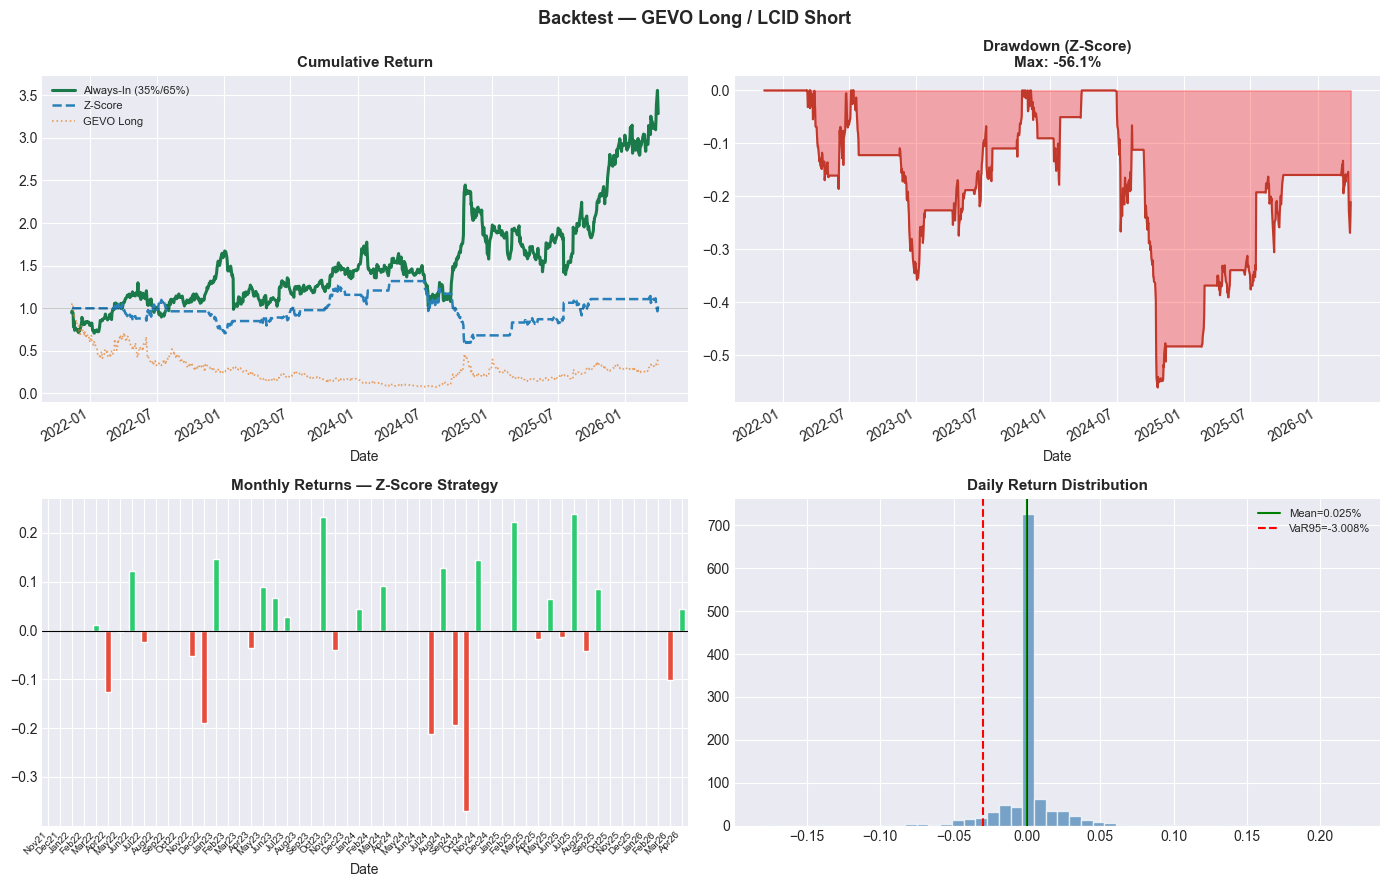

In [6]:
def perf_stats(r, label='', rf=RISK_FREE_RATE):
    r = r.dropna()
    ann_r = (1 + r).prod() ** (252 / len(r)) - 1
    ann_v = r.std() * np.sqrt(252)
    cum   = (1 + r).cumprod()
    mdd   = ((cum / cum.cummax()) - 1).min()
    return pd.Series({
        'Ann Return':  f'{ann_r:.2%}',
        'Ann Vol':     f'{ann_v:.2%}',
        'Sharpe':      f'{(ann_r - rf) / ann_v:.3f}' if ann_v > 0 else 'N/A',
        'Max DD':      f'{mdd:.2%}',
        'Calmar':      f'{ann_r / abs(mdd):.3f}' if mdd != 0 else 'N/A',
        'Win Rate':    f'{(r > 0).mean():.2%}',
        'Skew':        f'{stats.skew(r):.3f}',
    }, name=label)

spread_always = bt_df['spread_ret_opt'].dropna()
spread_zscore = bt_df['strat_ret_zscore'].dropna()

cum_always = (1 + spread_always).cumprod()
cum_zscore = (1 + spread_zscore).cumprod()
cum_long   = (1 + rl.reindex(spread_always.index)).cumprod()
cum_short  = (1 + rs.reindex(spread_always.index)).cumprod()

perf_table = pd.concat([
    perf_stats(spread_always, f'Always-In ({W_LONG:.0%}L/{W_SHORT:.0%}S)'),
    perf_stats(spread_zscore, f'Z-Score Strategy'),
    perf_stats(rl, f'{LONG_S} Long Only'),
    perf_stats(-rs, f'{SHORT_S} Short Only'),
], axis=1)

print('Performance Comparison:')
display(perf_table)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Cumulative
cum_always.plot(ax=axes[0, 0], color='#1a7a4a', lw=2.2, label=f'Always-In ({W_LONG:.0%}/{W_SHORT:.0%})')
cum_zscore.plot(ax=axes[0, 0], color='#2980b9', lw=1.8, linestyle='--', label='Z-Score')
cum_long.plot(ax=axes[0, 0], color='#e67e22', lw=1.2, linestyle=':', alpha=0.7, label=f'{LONG_S} Long')
axes[0, 0].axhline(1, color='black', lw=0.5, alpha=0.3)
axes[0, 0].set_title('Cumulative Return', fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=8)

# Drawdown
dd_z = (cum_zscore / cum_zscore.cummax()) - 1
dd_z.plot(ax=axes[0, 1], color='#c0392b', lw=1.5)
axes[0, 1].fill_between(dd_z.index, dd_z, 0, alpha=0.3, color='red')
axes[0, 1].set_title(f'Drawdown (Z-Score)\nMax: {dd_z.min():.1%}', fontsize=11, fontweight='bold')

# Monthly bar
monthly = spread_zscore.resample('ME').apply(lambda x: (1+x).prod()-1)
colors_m = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly.values]
monthly.plot(kind='bar', ax=axes[1, 0], color=colors_m, edgecolor='white')
axes[1, 0].axhline(0, color='black', lw=0.8)
axes[1, 0].set_xticklabels([d.strftime('%b%y') for d in monthly.index], rotation=45, ha='right', fontsize=7)
axes[1, 0].set_title('Monthly Returns — Z-Score Strategy', fontsize=11, fontweight='bold')

# Return distribution
spread_zscore.hist(bins=50, ax=axes[1, 1], color='steelblue', edgecolor='white', alpha=0.7)
axes[1, 1].axvline(spread_zscore.mean(), color='green', lw=1.5, label=f'Mean={spread_zscore.mean():.3%}')
var95 = np.percentile(spread_zscore.dropna(), 5)
axes[1, 1].axvline(var95, color='red', lw=1.5, linestyle='--', label=f'VaR95={var95:.3%}')
axes[1, 1].axvline(0, color='black', lw=0.6, alpha=0.5)
axes[1, 1].set_title('Daily Return Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=8)

plt.suptitle(f'Backtest — {LONG_S} Long / {SHORT_S} Short', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '06_backtest_report.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print('Weight Split Analysis')
print('=' * 50)
print(f'Dollar-neutral  (50/50) : ratio = 1.00')
print(f'Beta-neutral            : ratio = {meta["beta_neutral_ratio"]:.2f}')
print(f'Optimal (max Sharpe)    : ratio = {RATIO:.2f}  →  {W_LONG:.1%} long / {W_SHORT:.1%} short')
print()

# Show what the split means in intuitive terms
if RATIO > 1.0:
    print(f'  Overweights the LONG: {LONG_S} has lower beta or higher alpha per unit of risk.')
else:
    print(f'  Overweights the SHORT: {SHORT_S} provides stronger hedging per dollar allocated.')

print(f'  w_long = {RATIO:.2f}/(1+{RATIO:.2f}) = {W_LONG:.4f}')
print(f'  w_short= 1/(1+{RATIO:.2f}) = {W_SHORT:.4f}')
print()
print(f'Screening rank: #{int(screen.index.get_loc(SHORT_S)) + 1} of {len(screen)} candidates')
print(f'Always-in Sharpe   : {meta["sharpe_always_in"]:.3f}')
print(f'Z-score strategy   : {meta["sharpe_zscore"]:.3f}')
print(f'Full-period corr   : {rl.corr(rs):.3f}')
print(f'Current z-score    : {meta["current_zscore"]:.3f}  → {"LONG SPREAD" if meta["current_signal"]==1 else "SHORT SPREAD" if meta["current_signal"]==-1 else "FLAT"}')

Weight Split Analysis
Dollar-neutral  (50/50) : ratio = 1.00
Beta-neutral            : ratio = 0.67
Optimal (max Sharpe)    : ratio = 0.55  →  35.5% long / 64.5% short

  Overweights the SHORT: LCID provides stronger hedging per dollar allocated.
  w_long = 0.55/(1+0.55) = 0.3548
  w_short= 1/(1+0.55) = 0.6452

Screening rank: #3 of 15 candidates
Always-in Sharpe   : 0.510
Z-score strategy   : -0.122
Full-period corr   : 0.340
Current z-score    : 1.676  → SHORT SPREAD


### Alternative strategy: Z-Score mean reversion
The z-score signal is the timed version of the same pair trade.

What it means:
- We first build the spread between the long and short legs.
- Then we compare the current log price ratio to its recent rolling mean and standard deviation.
- A **positive z-score** means the spread is stretched high, so the notebook suggests **SHORT SPREAD**.
- A **negative z-score** means the spread is stretched low, so the notebook suggests **LONG SPREAD**.

Why use it:
- It is an alternative to always being in the trade.
- It only enters when the spread looks statistically unusual.
- That can reduce noise and avoid holding the pair when the spread is near fair value.

In this report, the current z-score is just a live signal check: it tells you whether the pair looks stretched enough to trade right now.

In [8]:
# Show full pair screening leaderboard with best pair highlighted
top_n = min(15, len(screen))
display_cols = ['always_sharpe', 'always_ret', 'always_maxdd', 'zscore_sharpe',
                'ret_correlation', 'n_signals']
leaderboard = screen.head(top_n)[display_cols].copy()
leaderboard.columns = ['Always-In Sharpe', 'Ann Ret', 'Max DD',
                        'Z-Score Sharpe', 'Corr(L,S)', '# Signals']
leaderboard['Ann Ret'] = leaderboard['Ann Ret'].map('{:.1%}'.format)
leaderboard['Max DD']  = leaderboard['Max DD'].map('{:.1%}'.format)

def highlight_best(row):
    return ['background-color: #d5f5e3; font-weight: bold'
            if row.name == SHORT_S else '' for _ in row]

print(f'Top {top_n} Short Candidates (ranked by Always-In Sharpe):')
display(leaderboard.style.apply(highlight_best, axis=1).format({
    'Always-In Sharpe': '{:.3f}',
    'Z-Score Sharpe':   '{:.3f}',
    'Corr(L,S)':        '{:.3f}',
    '# Signals':        '{:.0f}',
}))

Top 15 Short Candidates (ranked by Always-In Sharpe):


,Always-In Sharpe,Ann Ret,Max DD,Z-Score Sharpe,"Corr(L,S)",# Signals
Short,,,,,,
GOEV,1.055,75.4%,-57.1%,-0.643,0.190,33
CHPT,0.758,40.6%,-44.3%,-0.488,0.428,39
LCID,0.411,25.7%,-45.9%,-0.081,0.340,31
PLUG,0.016,5.8%,-53.0%,-0.115,0.426,33
RIVN,-0.037,3.2%,-59.1%,-0.189,0.340,35
REI,-0.109,-0.0%,-63.9%,-0.426,0.340,30
GPRE,-0.116,-0.2%,-56.6%,-0.276,0.388,36
AMTX,-0.205,-5.5%,-72.5%,-0.461,0.432,27
HYLN,-0.215,-5.9%,-69.6%,-0.128,0.368,37


In [9]:
print()
print('╔' + '═' * 60 + '╗')
print('║  INVESTMENT THESIS SUMMARY'.ljust(61) + '║')
print('╠' + '═' * 60 + '╣')
print(f'║  LONG  : {LONG_S:<51}║')
print(f'║  SHORT : {SHORT_S:<51}║')
print(f'║  Split : {W_LONG:.0%} long / {W_SHORT:.0%} short  (ratio {RATIO:.2f}x)'.ljust(61) + '║')
print('╠' + '═' * 60 + '╣')
print(f'║  Backtest Sharpe (always-in)  : {meta["sharpe_always_in"]:>6.3f}'.ljust(61) + '║')
print(f'║  Backtest Sharpe (z-score)    : {meta["sharpe_zscore"]:>6.3f}'.ljust(61) + '║')
print(f'║  Ann. Return (always-in)      : {meta["ann_ret_always"]:>6.1%}'.ljust(61) + '║')
print(f'║  Ann. Vol (always-in)         : {meta["ann_vol_always"]:>6.1%}'.ljust(61) + '║')
print(f'║  Max Drawdown (always-in)     : {meta["max_dd_always"]:>6.1%}'.ljust(61) + '║')
print('╠' + '═' * 60 + '╣')
print(f'║  Return correlation           : {rl.corr(rs):>6.3f}'.ljust(61) + '║')
print(f'║  Beta ({LONG_S})               : {meta["beta_long"]:>6.3f}'.ljust(61) + '║')
print(f'║  Beta ({SHORT_S})              : {meta["beta_short"]:>6.3f}'.ljust(61) + '║')
print(f'║  Beta-neutral ratio           : {meta["beta_neutral_ratio"]:>6.2f}x'.ljust(61) + '║')
print('╠' + '═' * 60 + '╣')
cur_sig = meta['current_signal']
sig_str = 'LONG SPREAD ← ACTIVE' if cur_sig == 1 else 'SHORT SPREAD ← ACTIVE' if cur_sig == -1 else 'FLAT'
print(f'║  Current z-score              : {meta["current_zscore"]:>+6.2f}'.ljust(61) + '║')
print(f'║  Current signal               : {sig_str:<28}║')
print('╚' + '═' * 60 + '╝')
print()
print('Output files:')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  outputs/{fn}')


╔════════════════════════════════════════════════════════════╗
║  INVESTMENT THESIS SUMMARY                                 ║
╠════════════════════════════════════════════════════════════╣
║  LONG  : GEVO                                               ║
║  SHORT : LCID                                               ║
║  Split : 35% long / 65% short  (ratio 0.55x)               ║
╠════════════════════════════════════════════════════════════╣
║  Backtest Sharpe (always-in)  :  0.510                     ║
║  Backtest Sharpe (z-score)    : -0.122                     ║
║  Ann. Return (always-in)      :  31.3%                     ║
║  Ann. Vol (always-in)         :  51.6%                     ║
║  Max Drawdown (always-in)     : -42.9%                     ║
╠════════════════════════════════════════════════════════════╣
║  Return correlation           :  0.340                     ║
║  Beta (GEVO)               :  2.433                        ║
║  Beta (LCID)              :  1.619                